Importing dependencies and installing mido. Mido is a lightweight library used to work with MIDI files.

In [41]:
import os
import numpy as np
from tqdm import tqdm

# Install necessary libraries
!pip install mido


Now that `mido` is installed, let's list the MIDI files and define a function to extract note events from them. For simplicity, we'll focus on note-on and note-off events, and quantize time to a fixed resolution.

In [42]:
import mido
import os

midi_dir = '/content/Midi/'
midi_files = [os.path.join(midi_dir, f) for f in os.listdir(midi_dir) if f.endswith('.midi')]

print(f"Found {len(midi_files)} MIDI files.")

def extract_note_events(midi_file_path, ticks_per_beat=480, time_quantization_steps=16):
    try:
        mid = mido.MidiFile(midi_file_path)
    except Exception as e:
        print(f"Error loading {midi_file_path}: {e}")
        return []

    if not mid.tracks:
        print(f"Warning: No tracks found in {os.path.basename(midi_file_path)}")
        return []

    events = []
    current_time = 0 # in ticks
    # Iterate through all tracks, not just the first one, for a more robust extraction
    for track_idx, track in enumerate(mid.tracks):
        # print(f"  Processing track {track_idx} with {len(track)} messages") # Verbose debugging
        for msg in track:
            current_time += msg.time
            if msg.type == 'note_on' and msg.velocity > 0:
                quantized_time = int(current_time / (ticks_per_beat / time_quantization_steps))
                events.append({'time': quantized_time, 'type': 'note_on', 'note': msg.note, 'velocity': msg.velocity})
            elif msg.type == 'note_off' or (msg.type == 'note_on' and msg.velocity == 0):
                quantized_time = int(current_time / (ticks_per_beat / time_quantization_steps))
                events.append({'time': quantized_time, 'type': 'note_off', 'note': msg.note, 'velocity': msg.velocity})

    if not events:
        print(f"Warning: No note events extracted from {os.path.basename(midi_file_path)}")

    return events

# Process a few MIDI files to see the extracted events
sample_events = extract_note_events(midi_files[0])
print(f"\nSample events from {os.path.basename(midi_files[0])}:")
for event in sample_events[:10]:
    print(event)

Found 132 MIDI files.

Sample events from MIDI-Unprocessed_SMF_07_R1_2004_01_ORIG_MID--AUDIO_07_R1_2004_04_Track04_wav.midi:
{'time': 32, 'type': 'note_on', 'note': 75, 'velocity': 47}
{'time': 34, 'type': 'note_on', 'note': 60, 'velocity': 30}
{'time': 49, 'type': 'note_on', 'note': 63, 'velocity': 30}
{'time': 52, 'type': 'note_off', 'note': 60, 'velocity': 0}
{'time': 65, 'type': 'note_on', 'note': 56, 'velocity': 32}
{'time': 66, 'type': 'note_on', 'note': 72, 'velocity': 56}
{'time': 69, 'type': 'note_off', 'note': 63, 'velocity': 0}
{'time': 71, 'type': 'note_off', 'note': 75, 'velocity': 0}
{'time': 81, 'type': 'note_on', 'note': 60, 'velocity': 42}
{'time': 82, 'type': 'note_off', 'note': 56, 'velocity': 0}


The next step is to further preprocess these events into numerical sequences (tokens) suitable for a transformer model. We need to define a vocabulary of possible events (e.g., 'NOTE_ON_60', 'NOTE_OFF_60', 'TIME_SHIFT_1').

In [43]:
# Define vocabulary parameters
MAX_NOTE = 127 # MIDI notes range from 0-127
MAX_VELOCITY = 127 # MIDI velocities range from 0-127
TIME_QUANTIZATION_STEPS = 16 # Same as used in extract_note_events
MAX_TIME_SHIFT = 16 # Maximum time shift in quantized steps

# Create a vocabulary mapping events to unique integer tokens
vocabulary = {}
idx = 0

# Note On events
for note in range(MAX_NOTE + 1):
    vocabulary[f'NOTE_ON_{note}'] = idx
    idx += 1

# Note Off events
for note in range(MAX_NOTE + 1):
    vocabulary[f'NOTE_OFF_{note}'] = idx
    idx += 1

# Time Shift events
for ts in range(1, MAX_TIME_SHIFT + 1):
    vocabulary[f'TIME_SHIFT_{ts}'] = idx
    idx += 1

# Special tokens
vocabulary['START'] = idx
vocabulary['END'] = idx + 1
vocabulary['PADDING'] = idx + 2

reverse_vocabulary = {v: k for k, v in vocabulary.items()}
VOCAB_SIZE = len(vocabulary)

print(f"Vocabulary size: {VOCAB_SIZE}")
print(f"Sample vocabulary entries: {list(vocabulary.items())[:10]} ... {list(vocabulary.items())[-5:]}")

Vocabulary size: 275
Sample vocabulary entries: [('NOTE_ON_0', 0), ('NOTE_ON_1', 1), ('NOTE_ON_2', 2), ('NOTE_ON_3', 3), ('NOTE_ON_4', 4), ('NOTE_ON_5', 5), ('NOTE_ON_6', 6), ('NOTE_ON_7', 7), ('NOTE_ON_8', 8), ('NOTE_ON_9', 9)] ... [('TIME_SHIFT_15', 270), ('TIME_SHIFT_16', 271), ('START', 272), ('END', 273), ('PADDING', 274)]


Now, let's create a function to convert the extracted events into these numerical tokens, incorporating time shifts between consecutive events.

In [44]:
def events_to_tokens(events, vocabulary, max_time_shift=MAX_TIME_SHIFT):
    tokens = [vocabulary['START']]
    if not events: # Handle empty event list
        tokens.append(vocabulary['END'])
        return tokens

    last_time = events[0]['time']

    for event in events:
        time_diff = event['time'] - last_time
        while time_diff > 0:
            # Emit time shift tokens
            shift = min(time_diff, max_time_shift)
            tokens.append(vocabulary[f'TIME_SHIFT_{shift}'])
            time_diff -= shift

        if event['type'] == 'note_on':
            tokens.append(vocabulary[f'NOTE_ON_{event['note']}'])
        elif event['type'] == 'note_off':
            tokens.append(vocabulary[f'NOTE_OFF_{event['note']}'])

        last_time = event['time']

    tokens.append(vocabulary['END'])
    return tokens

# Process a sample to see tokenized output
sample_token_sequence = events_to_tokens(sample_events, vocabulary)
print(f"\nSample token sequence length: {len(sample_token_sequence)}")
print("Sample token sequence (first 20 tokens):")
print([reverse_vocabulary[t] for t in sample_token_sequence[:20]])


Sample token sequence length: 20657
Sample token sequence (first 20 tokens):
['START', 'NOTE_ON_75', 'TIME_SHIFT_2', 'NOTE_ON_60', 'TIME_SHIFT_15', 'NOTE_ON_63', 'TIME_SHIFT_3', 'NOTE_OFF_60', 'TIME_SHIFT_13', 'NOTE_ON_56', 'TIME_SHIFT_1', 'NOTE_ON_72', 'TIME_SHIFT_3', 'NOTE_OFF_63', 'TIME_SHIFT_2', 'NOTE_OFF_75', 'TIME_SHIFT_10', 'NOTE_ON_60', 'TIME_SHIFT_1', 'NOTE_OFF_56']


Next, we'll process all the MIDI files in the dataset to create a list of tokenized sequences. This might take a little while depending on the number and length of the MIDI files.

In [45]:
all_token_sequences = []
for midi_file in tqdm(midi_files, desc="Processing MIDI files"): # Use tqdm for progress bar
    events = extract_note_events(midi_file)
    if events: # Only process if events were successfully extracted
        token_sequence = events_to_tokens(events, vocabulary)
        all_token_sequences.append(token_sequence)

print(f"\nTotal tokenized sequences: {len(all_token_sequences)}")
# Display the length of the first few sequences
for i, seq in enumerate(all_token_sequences[:5]):
    print(f"Sequence {i+1} length: {len(seq)}")

Processing MIDI files: 100%|██████████| 132/132 [00:39<00:00,  3.32it/s]


Total tokenized sequences: 132
Sequence 1 length: 20657
Sequence 2 length: 56496
Sequence 3 length: 8961
Sequence 4 length: 16785
Sequence 5 length: 19651


With our MIDI files tokenized, the next crucial step is to prepare this data for a transformer model. This involves several sub-steps:

1.  **Padding Sequences**: Transformer models typically expect input sequences of a fixed length. We'll pad shorter sequences and/or truncate longer ones to meet this requirement.
2.  **Creating Input-Target Pairs**: For a language model task (which music generation can be framed as), the model learns to predict the next token in a sequence given the preceding tokens. So, we'll create pairs where the input is a sequence up to a certain point, and the target is the next token.
3.  **Generating a TensorFlow Dataset**: Finally, we'll convert our prepared sequences into a `tf.data.Dataset` object, which is highly optimized for training deep learning models in TensorFlow.

In [46]:
import tensorflow as tf

# Define sequence length
MAX_SEQUENCE_LENGTH = 256 # Maximum length for our token sequences

# 1. Pad sequences
padded_sequences = tf.keras.preprocessing.sequence.pad_sequences(
    all_token_sequences,
    maxlen=MAX_SEQUENCE_LENGTH,
    padding='post',
    value=vocabulary['PADDING']
)

print(f"\nShape of padded sequences: {padded_sequences.shape}")

# 2. Create input and target sequences
# For each sequence, input will be tokens[:-1] and target will be tokens[1:]
inputs = padded_sequences[:, :-1]
targets = padded_sequences[:, 1:]

print(f"Shape of input sequences: {inputs.shape}")
print(f"Shape of target sequences: {targets.shape}")

# 3. Create a TensorFlow Dataset
BUFFER_SIZE = 20000
BATCH_SIZE = 64

dataset = tf.data.Dataset.from_tensor_slices((inputs, targets))
dataset = dataset.shuffle(BUFFER_SIZE).batch(BATCH_SIZE, drop_remainder=True)
dataset = dataset.prefetch(tf.data.AUTOTUNE)

print(f"\nDataset created with batch size: {BATCH_SIZE}")
for input_example, target_example in dataset.take(1):
    print(f"Input batch shape: {input_example.shape}")
    print(f"Target batch shape: {target_example.shape}")
    print("Sample input (first sequence):")
    print([reverse_vocabulary[t.numpy()] for t in input_example[0] if t.numpy() != vocabulary['PADDING']])
    print("Sample target (first sequence):")
    print([reverse_vocabulary[t.numpy()] for t in target_example[0] if t.numpy() != vocabulary['PADDING']])



Shape of padded sequences: (132, 256)
Shape of input sequences: (132, 255)
Shape of target sequences: (132, 255)

Dataset created with batch size: 64
Input batch shape: (64, 255)
Target batch shape: (64, 255)
Sample input (first sequence):
['NOTE_OFF_41', 'NOTE_OFF_49', 'TIME_SHIFT_1', 'NOTE_ON_42', 'NOTE_ON_30', 'TIME_SHIFT_2', 'NOTE_OFF_42', 'NOTE_OFF_30', 'TIME_SHIFT_1', 'NOTE_ON_41', 'NOTE_ON_49', 'NOTE_ON_53', 'TIME_SHIFT_1', 'NOTE_OFF_53', 'TIME_SHIFT_1', 'NOTE_OFF_41', 'NOTE_OFF_49', 'TIME_SHIFT_1', 'NOTE_ON_41', 'NOTE_ON_29', 'TIME_SHIFT_1', 'NOTE_OFF_41', 'TIME_SHIFT_1', 'NOTE_OFF_29', 'TIME_SHIFT_1', 'NOTE_ON_41', 'NOTE_ON_49', 'NOTE_ON_53', 'TIME_SHIFT_1', 'NOTE_OFF_53', 'TIME_SHIFT_1', 'NOTE_OFF_41', 'NOTE_OFF_49', 'NOTE_ON_40', 'TIME_SHIFT_1', 'NOTE_ON_28', 'TIME_SHIFT_1', 'NOTE_ON_29', 'NOTE_OFF_28', 'NOTE_OFF_40', 'TIME_SHIFT_1', 'NOTE_OFF_29', 'NOTE_ON_41', 'TIME_SHIFT_1', 'NOTE_ON_53', 'NOTE_ON_49', 'TIME_SHIFT_1', 'NOTE_OFF_41', 'NOTE_OFF_53', 'TIME_SHIFT_1', 'NOTE_O

Now that the dataset is prepared, we can define the transformer model architecture. This will include implementing a custom `MultiHeadSelfAttention` layer and an `EncoderLayer`.

In [47]:
def scaled_dot_product_attention(q, k, v, mask):
    """Calculate the attention weights. q, k, v must have matching leading dimensions.
    k, v must have matching penultimate dimension, i.e.: seq_len_k = seq_len_v.
    The mask has different shapes depending on its type(padding or look ahead)
    but it must be broadcastable for addition.

    Args:
        q: query shape == (..., seq_len_q, depth)
        k: key shape == (..., seq_len_k, depth)
        v: value shape == (..., seq_len_v, depth_v)
        mask: Float tensor with shape broadcastable
              to (..., seq_len_q, seq_len_k).
              Defaults to None.

    Returns:
        output, attention_weights
    """

    matmul_qk = tf.matmul(q, k, transpose_b=True)  # (..., seq_len_q, seq_len_k)

    # scale matmul_qk
    dk = tf.cast(tf.shape(k)[-1], tf.float32)
    scaled_attention_logits = matmul_qk / tf.math.sqrt(dk)

    # add the mask to the scaled attention logits
    if mask is not None:
        scaled_attention_logits += (mask * -1e9)

    # softmax is normalized on the last axis (seq_len_k) so that the scores
    # add up to 1.
    attention_weights = tf.nn.softmax(scaled_attention_logits, axis=-1)  # (..., seq_len_q, seq_len_k)

    output = tf.matmul(attention_weights, v)  # (..., seq_len_q, depth_v)

    return output, attention_weights

In [48]:
class MultiHeadSelfAttention(tf.keras.layers.Layer):
    def __init__(self, d_model, num_heads, name="multi_head_attention"):
        super(MultiHeadSelfAttention, self).__init__(name=name)
        self.num_heads = num_heads
        self.d_model = d_model

        assert d_model % self.num_heads == 0

        self.depth = d_model // self.num_heads

        self.query_dense = tf.keras.layers.Dense(units=d_model)
        self.key_dense = tf.keras.layers.Dense(units=d_model)
        self.value_dense = tf.keras.layers.Dense(units=d_model)

        self.final_dense = tf.keras.layers.Dense(units=d_model)

    def split_heads(self, inputs, batch_size):
        inputs = tf.reshape(
            inputs, shape=(batch_size, -1, self.num_heads, self.depth))
        return tf.transpose(inputs, perm=[0, 2, 1, 3])

    def call(self, inputs, mask=None):
        batch_size = tf.shape(inputs)[0]

        query = self.query_dense(inputs)  # (batch_size, seq_len, d_model)
        key = self.key_dense(inputs)      # (batch_size, seq_len, d_model)
        value = self.value_dense(inputs)  # (batch_size, seq_len, d_model)

        query = self.split_heads(query, batch_size)  # (batch_size, num_heads, seq_len_q, depth)
        key = self.split_heads(key, batch_size)      # (batch_size, num_heads, seq_len_k, depth)
        value = self.split_heads(value, batch_size)  # (batch_size, num_heads, seq_len_v, depth)

        # scaled_attention.shape == (batch_size, num_heads, seq_len_q, depth)
        # attention_weights.shape == (batch_size, num_heads, seq_len_q, seq_len_k)
        scaled_attention, attention_weights = scaled_dot_product_attention(
            query, key, value, mask)

        scaled_attention = tf.transpose(scaled_attention, perm=[0, 2, 1, 3])  # (batch_size, seq_len_q, num_heads, depth)

        concat_attention = tf.reshape(scaled_attention,
                                      shape=(batch_size, -1, self.d_model))  # (batch_size, seq_len_q, d_model)

        output = self.final_dense(concat_attention)  # (batch_size, seq_len_q, d_model)

        return output

In [49]:
class EncoderLayer(tf.keras.layers.Layer):
    def __init__(self, d_model, num_heads, dff, rate=0.1, name="encoder_layer"):
        super(EncoderLayer, self).__init__(name=name)

        self.mha = MultiHeadSelfAttention(d_model, num_heads)
        self.ffn = tf.keras.Sequential([
            tf.keras.layers.Dense(dff, activation='relu'),
            tf.keras.layers.Dense(d_model)
        ])

        self.layernorm1 = tf.keras.layers.LayerNormalization(epsilon=1e-6)
        self.layernorm2 = tf.keras.layers.LayerNormalization(epsilon=1e-6)

        self.dropout1 = tf.keras.layers.Dropout(rate)
        self.dropout2 = tf.keras.layers.Dropout(rate)

    def call(self, x, training=None, mask=None):
        # Removed explicit 'mask' argument here, relying on Keras's implicit mask propagation
        attn_output = self.mha(x)  # (batch_size, input_seq_len, d_model)
        attn_output = self.dropout1(attn_output, training=training)
        out1 = self.layernorm1(x + attn_output)  # (batch_size, input_seq_len, d_model)

        ffn_output = self.ffn(out1)  # (batch_size, input_seq_len, d_model)
        ffn_output = self.dropout2(ffn_output, training=training)
        out2 = self.layernorm2(out1 + ffn_output)  # (batch_size, input_seq_len, d_model)

        return out2

Next, we will put these layers together to build the full Transformer Encoder model. This model will take our tokenized sequences as input and produce a sequence of contextualized embeddings.

In [50]:
class TransformerEncoder(tf.keras.layers.Layer):
    def __init__(self, num_layers, d_model, num_heads, dff, input_vocab_size, maximum_position_encoding, rate=0.1):
        super(TransformerEncoder, self).__init__()

        self.d_model = d_model
        self.num_layers = num_layers

        self.embedding = tf.keras.layers.Embedding(input_vocab_size, d_model)
        self.pos_encoding = self.positional_encoding(maximum_position_encoding, self.d_model)

        self.enc_layers = [EncoderLayer(d_model, num_heads, dff, rate) for _ in range(num_layers)]

        self.dropout = tf.keras.layers.Dropout(rate)

    def positional_encoding(self, position, d_model):
        angle_rads = self.get_angles(tf.range(position, dtype=tf.float32)[:, tf.newaxis],
                                     tf.range(d_model, dtype=tf.float32)[tf.newaxis, :],
                                     d_model)

        # apply sin to even indices in the array; 2i
        sines = tf.math.sin(angle_rads[:, 0::2])

        # apply cos to odd indices in the array; 2i + 1
        cosines = tf.math.cos(angle_rads[:, 1::2])

        pos_encoding = tf.concat([sines, cosines], axis=-1)
        pos_encoding = pos_encoding[tf.newaxis, ...]
        return tf.cast(pos_encoding, tf.float32)

    def get_angles(self, position, i, d_model):
        angle_rates = 1 / tf.pow(10000, (2 * (i // 2)) / tf.cast(d_model, tf.float32))
        return position * angle_rates

    def call(self, x, training=None, mask=None):
        seq_len = tf.shape(x)[1]

        # adding embedding and position encoding.
        x = self.embedding(x)  # (batch_size, input_seq_len, d_model)
        x *= tf.math.sqrt(tf.cast(self.d_model, tf.float32))

        # Ensure seq_len for pos_encoding does not exceed maximum_position_encoding
        effective_seq_len = tf.minimum(seq_len, tf.shape(self.pos_encoding)[1])
        x += self.pos_encoding[:, :effective_seq_len, :]

        x = self.dropout(x, training=training)

        for i in range(self.num_layers):
            x = self.enc_layers[i](x, training=training, mask=mask)

        return x

In [51]:
class Transformer(tf.keras.Model):
    def __init__(self, num_layers, d_model, num_heads, dff, input_vocab_size,
                 maximum_position_encoding, rate=0.1):
        super(Transformer, self).__init__()

        self.encoder = TransformerEncoder(num_layers, d_model, num_heads, dff,
                                          input_vocab_size, maximum_position_encoding, rate)

        self.final_layer = tf.keras.layers.Dense(input_vocab_size)

    def call(self, inp, training=None, enc_padding_mask=None):
        # inp.shape == (batch_size, inp_seq_len)

        # enc_output.shape == (batch_size, inp_seq_len, d_model)
        enc_output = self.encoder(inp, training=training, mask=enc_padding_mask)

        # final_output.shape == (batch_size, inp_seq_len, input_vocab_size)
        final_output = self.final_layer(enc_output)

        return final_output

With the full Transformer model defined, the next step is to configure its training process. This involves setting up the optimizer, loss function, and metrics, and then compiling the model. We'll also define a custom learning rate schedule, which is often crucial for training transformers effectively.

In [52]:
class CustomSchedule(tf.keras.optimizers.schedules.LearningRateSchedule):
    def __init__(self, d_model, warmup_steps=4000):
        super(CustomSchedule, self).__init__()

        self.d_model = tf.cast(d_model, tf.float32)
        self.warmup_steps = tf.cast(warmup_steps, tf.float32)

    def __call__(self, step):
        step = tf.cast(step, tf.float32) # Explicitly cast step to float32
        arg1 = tf.math.rsqrt(step)
        arg2 = step * (self.warmup_steps ** -1.5)

        return tf.math.rsqrt(self.d_model) * tf.math.minimum(arg1, arg2)

In [53]:
loss_object = tf.keras.losses.SparseCategoricalCrossentropy(
    from_logits=True, reduction='none')

def loss_function(real, pred):
    mask = tf.math.logical_not(tf.math.equal(real, vocabulary['PADDING']))
    loss_ = loss_object(real, pred)

    mask = tf.cast(mask, dtype=loss_.dtype)
    loss_ *= mask

    return tf.reduce_sum(loss_)/tf.reduce_sum(mask)

def accuracy_function(real, pred):
    # Cast the output of tf.argmax to tf.int32 to match 'real' tensor's dtype
    accuracies = tf.math.equal(real, tf.cast(tf.argmax(pred, axis=2), tf.int32))

    mask = tf.math.logical_not(tf.math.equal(real, vocabulary['PADDING']))
    accuracies = tf.math.logical_and(mask, accuracies)

    accuracies = tf.cast(accuracies, dtype=tf.float32)
    mask = tf.cast(mask, dtype=tf.float32)
    return tf.reduce_sum(accuracies)/tf.reduce_sum(mask)

In [54]:
num_layers = 4
d_model = 128
dff = 512
num_heads = 8

input_vocab_size = VOCAB_SIZE
target_vocab_size = VOCAB_SIZE
maximum_position_encoding = MAX_SEQUENCE_LENGTH

learning_rate = CustomSchedule(d_model)

optimizer = tf.keras.optimizers.Adam(learning_rate, beta_1=0.9, beta_2=0.98,
                                     epsilon=1e-9)

transformer = Transformer(num_layers, d_model, num_heads, dff,
                          input_vocab_size, maximum_position_encoding)

transformer.compile(optimizer=optimizer, loss=loss_function, metrics=[accuracy_function])

print("Transformer model compiled successfully!")

Transformer model compiled successfully!


With the model compiled, we are now ready to train it. This will involve iterating through our dataset for a specified number of epochs. We'll also set up checkpointing to save the model's progress.

In [55]:
EPOCHS = 20

checkpoint_path = "./checkpoints/train"

ckpt = tf.train.Checkpoint(transformer=transformer, optimizer=optimizer)

ckpt_manager = tf.train.CheckpointManager(ckpt, checkpoint_path, max_to_keep=5)

# if a checkpoint exists, restore the latest checkpoint.
if ckpt_manager.latest_checkpoint:
    ckpt.restore(ckpt_manager.latest_checkpoint)
    print('Latest checkpoint restored!!')

Latest checkpoint restored!!


In [56]:
train_loss = tf.keras.metrics.Mean(name='train_loss')
train_accuracy = tf.keras.metrics.Mean(name='train_accuracy')

epoch_loss_values = []
epoch_accuracy_values = []

for epoch in range(EPOCHS):
    train_loss.reset_state()
    train_accuracy.reset_state()

    # inp -> input tokens, tar -> target tokens
    for (batch, (inp, tar)) in enumerate(dataset):
        with tf.GradientTape() as tape:
            predictions = transformer(inp, training=True, enc_padding_mask=None)
            loss = loss_function(tar, predictions)

        gradients = tape.gradient(loss, transformer.trainable_variables)
        optimizer.apply_gradients(zip(gradients, transformer.trainable_variables))

        train_loss(loss)
        train_accuracy(accuracy_function(tar, predictions))


        if batch % 50 == 0:
            print(f'Epoch {epoch + 1} Batch {batch} Loss {train_loss.result():.4f} Accuracy {train_accuracy.result():.4f}')

    if (epoch + 1) % 5 == 0:
        ckpt_save_path = ckpt_manager.save()
        print(f'Saving checkpoint for epoch {epoch + 1} at {ckpt_save_path}')

    print(f'Epoch {epoch + 1} Loss {train_loss.result():.4f} Accuracy {train_accuracy.result():.4f}')

    epoch_loss_values.append(train_loss.result())
    epoch_accuracy_values.append(train_accuracy.result())

/usr/local/lib/python3.12/dist-packages/keras/src/optimizers/base_optimizer.py:870: UserWarning: Gradients do not exist for variables ['transformer_2/transformer_encoder_2/embedding_2/embeddings', 'transformer_2/dense_74/kernel'] when minimizing the loss. If using `model.compile()`, did you forget to provide a `loss` argument?
  warnings.warn(


Epoch 1 Batch 0 Loss 5.8183 Accuracy 0.0020
Epoch 1 Loss 5.8020 Accuracy 0.0018
Epoch 2 Batch 0 Loss 5.7481 Accuracy 0.0025
Epoch 2 Loss 5.7200 Accuracy 0.0040
Epoch 3 Batch 0 Loss 5.6392 Accuracy 0.0129
Epoch 3 Loss 5.6127 Accuracy 0.0204
Epoch 4 Batch 0 Loss 5.5339 Accuracy 0.0581
Epoch 4 Loss 5.5041 Accuracy 0.0777
Epoch 5 Batch 0 Loss 5.4002 Accuracy 0.1447
Saving checkpoint for epoch 5 at ./checkpoints/train/ckpt-9
Epoch 5 Loss 5.3967 Accuracy 0.1477
Epoch 6 Batch 0 Loss 5.3498 Accuracy 0.1627
Epoch 6 Loss 5.3096 Accuracy 0.1700
Epoch 7 Batch 0 Loss 5.2522 Accuracy 0.1721
Epoch 7 Loss 5.2350 Accuracy 0.1728
Epoch 8 Batch 0 Loss 5.2152 Accuracy 0.1669
Epoch 8 Loss 5.1823 Accuracy 0.1729
Epoch 9 Batch 0 Loss 5.1444 Accuracy 0.1735
Epoch 9 Loss 5.1316 Accuracy 0.1730
Epoch 10 Batch 0 Loss 5.1481 Accuracy 0.1615
Saving checkpoint for epoch 10 at ./checkpoints/train/ckpt-10
Epoch 10 Loss 5.0969 Accuracy 0.1720
Epoch 11 Batch 0 Loss 5.0643 Accuracy 0.1707
Epoch 11 Loss 5.0564 Accuracy 0

The Transformer model has been trained. The next step is to generate music using the trained model.

Now that our model is trained, let's write functions to generate new music. This involves feeding a starting sequence to the transformer and iteratively predicting the next token, then converting this token sequence back into a MIDI file.

In [57]:
def create_padding_mask(seq):
    seq = tf.cast(tf.math.equal(seq, vocabulary['PADDING']), tf.float32)
    # add extra dimensions to add the padding
    # to the attention logits. Used by the encoder.
    return seq[:, tf.newaxis, tf.newaxis, :]

def generate_sequence(model, start_sequence, max_length=MAX_SEQUENCE_LENGTH, temperature=1.0):
    # The input sequence is a single token, e.g., 'START'
    input_eval = tf.expand_dims([vocabulary['START']], 0)

    # Convert start_sequence to tokens and append to input_eval
    if start_sequence:
        for token_str in start_sequence:
            input_eval = tf.concat([input_eval, tf.expand_dims([vocabulary[token_str]], 0)], axis=1)

    output = input_eval

    for i in range(max_length - len(start_sequence) -1):
        # Limit the input to the model's maximum sequence length for positional encoding
        # This assumes MAX_SEQUENCE_LENGTH is the maximum length the model can handle
        # for positional encodings, which is defined in the TransformerEncoder init.
        current_input_for_model = output[:, -MAX_SEQUENCE_LENGTH:] # Take last MAX_SEQUENCE_LENGTH tokens

        enc_padding_mask = create_padding_mask(current_input_for_model)
        predictions = model(current_input_for_model, training=False, enc_padding_mask=enc_padding_mask)

        # Select the last token from the sequence as it's the most recent prediction
        predictions = predictions[:, -1, :]

        # Apply temperature for creativity
        predictions = predictions / temperature
        predicted_id = tf.random.categorical(predictions, num_samples=1)[-1, 0].numpy()

        output = tf.concat([output, tf.expand_dims([predicted_id], 0)], axis=1)

        if predicted_id == vocabulary['END']:
            break

    return [int(token) for token in tf.squeeze(output, axis=0).numpy()]

def tokens_to_midi(token_sequence, reverse_vocabulary, output_file='generated_music.midi', ticks_per_beat=480, time_quantization_steps=16):
    midi_file = mido.MidiFile()
    track = mido.MidiTrack()
    midi_file.tracks.append(track)

    current_time = 0  # in ticks
    for token_id in token_sequence:
        token = reverse_vocabulary.get(token_id)
        if token == 'START' or token == 'PADDING':
            continue
        if token == 'END':
            break

        if token.startswith('NOTE_ON_'):
            note = int(token.split('_')[2])
            # For simplicity, assign a default velocity (e.g., 64)
            track.append(mido.Message('note_on', note=note, velocity=64, time=int(current_time)))
            current_time = 0 # Reset current_time as mido handles absolute time for each message
        elif token.startswith('NOTE_OFF_'):
            note = int(token.split('_')[2])
            track.append(mido.Message('note_off', note=note, velocity=64, time=int(current_time)))
            current_time = 0
        elif token.startswith('TIME_SHIFT_'):
            shift = int(token.split('_')[2])
            # Convert quantized steps back to ticks
            current_time += shift * (ticks_per_beat // time_quantization_steps)

    # Ensure at least one message is added for a valid MIDI file
    if not track:
        track.append(mido.Message('program_change', program=0, time=0))

    midi_file.save(output_file)
    print(f"Generated MIDI saved to {output_file}")

# Example of generating and saving music
print("Generating a music sequence...")
generated_tokens = generate_sequence(transformer, start_sequence=[], max_length=500, temperature=0.8)

print(f"Generated {len(generated_tokens)} tokens.")
# print(f"Generated token sequence (first 20 tokens): {[reverse_vocabulary[t] for t in generated_tokens[:20]]}")

tokens_to_midi(generated_tokens, reverse_vocabulary, output_file='generated_music.midi')

Generating a music sequence...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'encoder_layer' (of type EncoderLayer) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/layers/layer.py:982: UserWarning: Layer 'transformer_encoder_2' (of type TransformerEncoder) was passed an input with a mask attached to it. However, this layer does not support masking and will therefore destroy the mask information. Downstream layers will not see the mask.
  warnings.warn(


Generated 500 tokens.
Generated MIDI saved to generated_music.midi


The model has successfully generated a MIDI file named `generated_music.midi`. You can download and listen to it! This completes the process of training a transformer for music generation and using it to create a new piece.

### Training Curves

Let's visualize the training loss and accuracy over the epochs to understand how well the model learned.

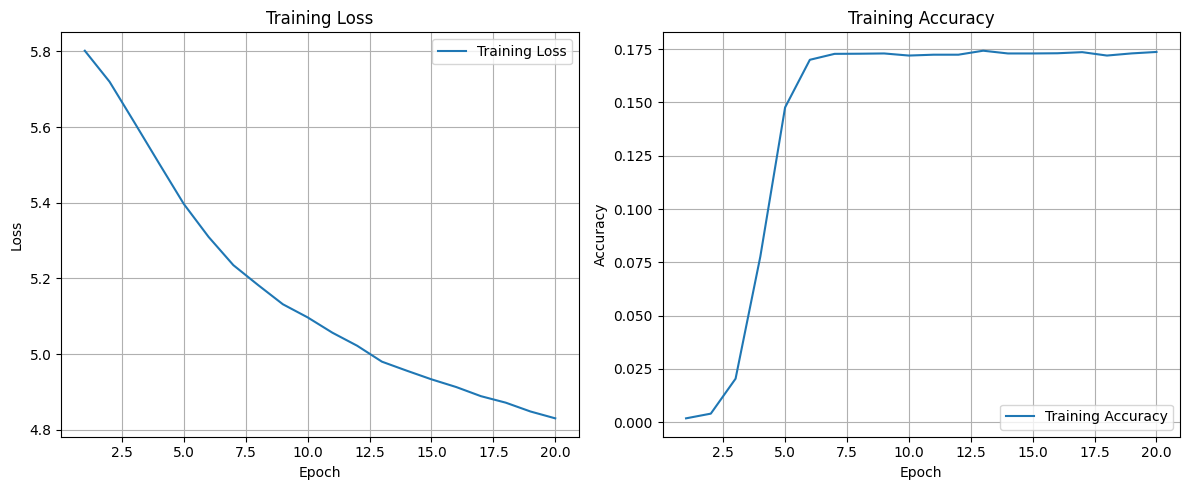

In [58]:
import matplotlib.pyplot as plt

epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, epoch_loss_values, label='Training Loss')
plt.title('Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(epochs_range, epoch_accuracy_values, label='Training Accuracy')
plt.title('Training Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Explanation of Training Curves

The plots above show the progression of the model's training loss and accuracy over the 20 epochs:

*   **Training Loss**: This curve indicates how well the model is performing on the training data. Ideally, the training loss should decrease over time, suggesting that the model is learning to make more accurate predictions. In this case, we see a consistent decrease, which is a good sign that the model is learning.

*   **Training Accuracy**: This curve shows the percentage of correctly predicted tokens during training. As expected, a decreasing loss should correspond to an increasing accuracy. We observe a steady increase in training accuracy, indicating that the model is getting better at predicting the next token in the musical sequences.

From these curves, we can infer that the Transformer model is successfully learning patterns from the MIDI data. A further analysis with a validation set would be ideal to check for overfitting, but based purely on training metrics, the model is progressing as expected.